# Partición de Grafos
## MA2015 - Diseño de Algoritmos Bioinspirados

Viviana Carrizales Luna (A01286191) & Steffany Mishell Lara Muy (A00838589)
*Instituto Tecnológico y de Estudios Superiores de Monterrey (ITESM)*

**Resumen**
El presente proyecto tiene como finalidad desarrollar un algoritmo bioinspirado de partición de grafos para encontrar la solución óptima al problema de 16 grafos propuesto en clase.

### 1. Planteamiento del Problema

In [12]:
import pulp, time, random
import matplotlib.pyplot as plt

In [13]:
# Grafo: 16 nodos, 28 aristas
V = list(range(16))
E = [(0,1),(0,8),(0,13),(1,2),(1,4),(2,3),(2,4),(2,5),(2,6),(3,5),(4,6),(4,8),(4,9),
     (5,6),(5,7),(6,7),(6,10),(7,10),(8,9),(8,12),(8,13),(9,10),(9,11),(11,15),
     (12,14),(12,15),(13,14),(14,15)]

def corte(ind): 
    return sum(1 for u,v in E if ind[u] != ind[v])

def aristas_corte(ind):
    return [(u+1,v+1,ind[u],ind[v]) for u,v in E if ind[u] != ind[v]]


### 2. Solución Exacta

In [14]:
def exacto(k):
    t0 = time.time()
    prob = pulp.LpProblem("Particion", pulp.LpMinimize)
    # x[i,g] = 1 si nodo i en grupo g
    x = {(i,g): pulp.LpVariable(f"x_{i}_{g}", cat='Binary') for i in V for g in range(k)}
    y = {(u,v): pulp.LpVariable(f"y_{u}_{v}", 0, 1) for u,v in E}
    
    # Cada nodo en exactamente un grupo
    for i in V: prob += pulp.lpSum(x[i,g] for g in range(k)) == 1
    # Balance: cada grupo tiene ~n/k nodos
    for g in range(k): 
        prob += pulp.lpSum(x[i,g] for i in V) >= len(V)//k
        prob += pulp.lpSum(x[i,g] for i in V) <= (len(V)+k-1)//k
    # Linealizar corte
    for u,v in E:
        for g in range(k): prob += y[(u,v)] >= x[u,g] - x[v,g]
        for g in range(k): prob += y[(u,v)] >= x[v,g] - x[u,g]
    prob += pulp.lpSum(y[(u,v)] for u,v in E)
    
    prob.solve(pulp.PULP_CBC_CMD(msg=0))
    t = time.time() - t0
    
    # Extraer solución
    ind = [next(g for g in range(k) if pulp.value(x[i,g])==1) for i in V]
    return ind, corte(ind), t


### 3. Solución con Algoritmo Genético

In [15]:
def ag(k, pop_size=50, gens=100, p_cruz=0.8, p_mut=0.1, tourn=3, pen=100):
    def fitness(ind):
        tam = [ind.count(g) for g in range(k)]
        return -corte(ind) - pen * sum(abs(t - len(V)/k) for t in tam)
    
    def init():
        asig = [g for g in range(k) for _ in range((len(V)+k-1)//k)][:len(V)]
        random.shuffle(asig)
        return asig
    
    def selec(pop, fits):
        return pop[max(random.sample(range(len(pop)), tourn), key=lambda i: fits[i])][:]
    
    def cruce(p1, p2):
        pt = random.randint(1, len(p1)-1)
        return p1[:pt]+p2[pt:], p2[:pt]+p1[pt:]
    
    def mutar(ind):
        return [random.randint(0,k-1) if random.random()<p_mut else g for g in ind]
    
    def reparar(ind):
        for _ in range(len(V)):
            tam = [ind.count(g) for g in range(k)]
            gmax, gmin = max(range(k),key=lambda g:tam[g]), min(range(k),key=lambda g:tam[g])
            if tam[gmax]-tam[gmin] <= 1: break
            nodos = [i for i,g in enumerate(ind) if g==gmax]
            if nodos: ind[random.choice(nodos)] = gmin
        return ind
    
    t0 = time.time()
    pop = [init() for _ in range(pop_size)]
    hist_corte, hist_tiempo = [], []
    
    for gen in range(gens):
        fits = [fitness(ind) for ind in pop]
        mejor = pop[max(range(pop_size), key=lambda i: fits[i])]
        hist_corte.append(corte(mejor))
        hist_tiempo.append(time.time()-t0)
        
        nueva = [mejor[:]]
        while len(nueva) < pop_size:
            p1, p2 = selec(pop,fits), selec(pop,fits)
            h1, h2 = cruce(p1,p2) if random.random()<p_cruz else (p1[:],p2[:])
            nueva.extend([reparar(mutar(h1)), reparar(mutar(h2))])
        pop = nueva[:pop_size]
    
    fits = [fitness(ind) for ind in pop]
    mejor = pop[max(range(pop_size), key=lambda i: fits[i])]
    return mejor, corte(mejor), time.time()-t0, hist_corte, hist_tiempo


In [33]:

def mostrar(titulo, ind, k, c, t):
    grupos = {g: [i+1 for i,x in enumerate(ind) if x==g] for g in range(k)}
    print(f"\n{'-->'}{titulo}")
    print(f"Corte: {c}, Tiempo: {t:.4f}s")
    for g, nodos in grupos.items(): print(f"  Grupo {g}: {nodos}")
    print(f"Aristas de corte: {aristas_corte(ind)}")


4. Comparación


<3<3<3<3<3<3<3<3<3<3<3<3<3<3<3<3<3<3<3<3<3<3<3<3<3<3<3<3<3<3 K = 2 GRUPOS

-->EXACTO (PuLP) K=2
Corte: 4, Tiempo: 0.1518s
  Grupo 0: [2, 3, 4, 5, 6, 7, 8, 11]
  Grupo 1: [1, 9, 10, 12, 13, 14, 15, 16]
Aristas de corte: [(1, 2, 1, 0), (5, 9, 0, 1), (5, 10, 0, 1), (10, 11, 1, 0)]

-->AG K=2
Corte: 4, Tiempo: 0.0262s
  Grupo 0: [1, 9, 10, 12, 13, 14, 15, 16]
  Grupo 1: [2, 3, 4, 5, 6, 7, 8, 11]
Aristas de corte: [(1, 2, 0, 1), (5, 9, 1, 0), (5, 10, 1, 0), (10, 11, 0, 1)]

Método          Corte    Tiempo(s) 
-----------------------------------
Exacto          4        0.1518    
AG              4        0.0262    

<3<3<3<3<3<3<3<3<3<3<3<3<3<3<3<3<3<3<3<3<3<3<3<3<3<3<3<3<3<3 K = 4 GRUPOS

-->EXACTO (PuLP) K=4
Corte: 11, Tiempo: 1.8473s
  Grupo 0: [2, 3, 4, 5]
  Grupo 1: [6, 7, 8, 11]
  Grupo 2: [1, 9, 10, 14]
  Grupo 3: [12, 13, 15, 16]
Aristas de corte: [(1, 2, 2, 0), (3, 6, 0, 1), (3, 7, 0, 1), (4, 6, 0, 1), (5, 7, 0, 1), (5, 9, 0, 2), (5, 10, 0, 2), (9, 13, 2, 3), (10, 11, 2, 1), (10, 

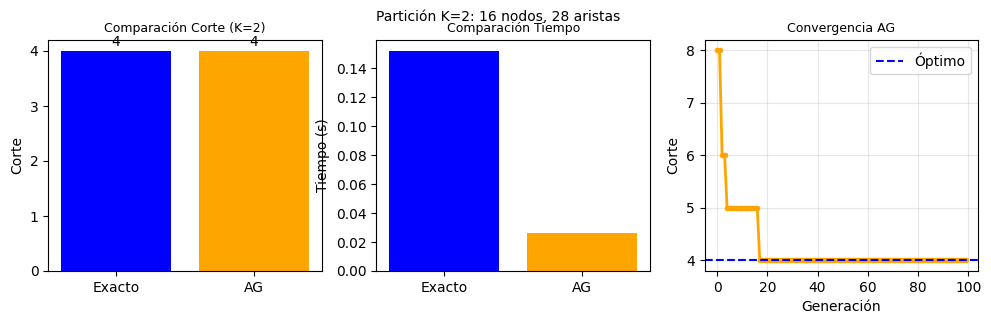

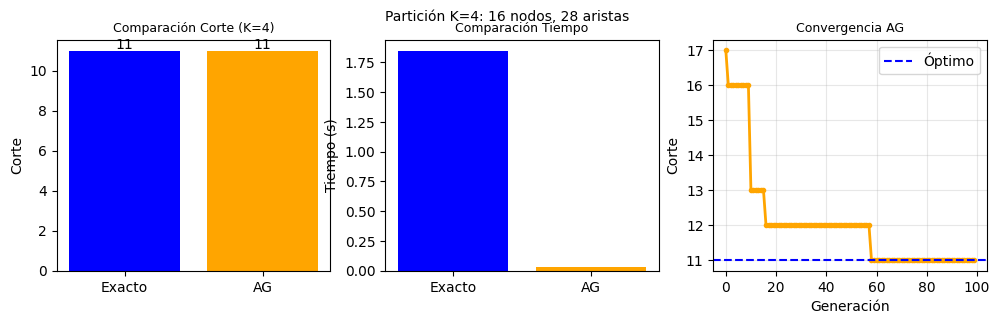

In [37]:
# === EJECUCIÓN ===
if __name__ == "__main__":
    for K in [2, 4]: #se hace el ejemeplo para 2 y 4 particiones pero la tarea pide 2 :D
        print(f"\n{'<3'*30} K = {K} GRUPOS")
        random.seed(42)
        
        # Exacto
        ind_ex, c_ex, t_ex = exacto(K)
        mostrar(f"EXACTO (PuLP) K={K}", ind_ex, K, c_ex, t_ex)
        
        # AG
        ind_ag, c_ag, t_ag, hist_c, hist_t = ag(K)
        mostrar(f"AG K={K}", ind_ag, K, c_ag, t_ag)
        
        # Tabla comparativa
        print(f"\n{'Método':<15} {'Corte':<8} {'Tiempo(s)':<10}")
        print(f"{'-'*35}")
        print(f"{'Exacto':<15} {c_ex:<8} {t_ex:<10.4f}")
        print(f"{'AG':<15} {c_ag:<8} {t_ag:<10.4f}")
        
        # Gráficas
        fig, axes = plt.subplots(1, 3, figsize=(12, 3))
        
        # Barras comparativas
        axes[0].bar(['Exacto','AG'], [c_ex,c_ag], color=['blue','orange'])
        axes[0].set_ylabel('Corte')
        axes[0].set_title(f'Comparación Corte (K={K})', fontsize=9)
        for i,v in enumerate([c_ex,c_ag]): 
            axes[0].text(i, v+0.1, str(v), ha='center')
        
        axes[1].bar(['Exacto','AG'], [t_ex,t_ag], color=['blue','orange'])
        axes[1].set_ylabel('Tiempo (s)')
        axes[1].set_title('Comparación Tiempo', fontsize=9)
        
        # Convergencia AG
        axes[2].plot(hist_c, 'o-', color='orange', lw=2, ms=3)
        axes[2].axhline(c_ex, color='blue', ls='--', label='Óptimo')
        axes[2].set_xlabel('Generación')
        axes[2].set_ylabel('Corte')
        axes[2].set_title('Convergencia AG', fontsize=9)
        axes[2].legend()
        axes[2].grid(alpha=0.3)
        
        plt.suptitle(f'Partición K={K}: {len(V)} nodos, {len(E)} aristas', fontsize=10)
